# VDUI Assignment
## SRN: PES2UG24CS311
## Name: Neeraj R Rugi

# Activity: QuickCart Delivery Analytics
### Applying Histograms, Density Plots & Proportions to a Real Business Question
Unit 1, Lecture 7 — Visualization of Data, Understanding and Interpretation (UE24CS342AA9)

---

## Scenario

You are a data analyst at **QuickCart**, an online delivery startup. The operations team
has asked you two questions ahead of tomorrow's planning meeting:

1. **"What does our delivery time actually look like?** Are we mostly fast, mostly slow,
   or is something more complicated going on?"
2. **"Which region should we prioritize for extra delivery staff?"**

You've been given delivery records for the last month. Your job is to visualize the data
correctly enough to give the ops team a confident answer — using the same tools from
today's lecture: histograms, bin width, density plots, bandwidth, and proportion charts.

Run the cell below to load your dataset — you do not need to change it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

# --- QuickCart delivery dataset (synthetic, seeded for reproducibility) ---
rng = np.random.default_rng(42)
n = 1200

regions = rng.choice(["North", "South", "East", "West", "Central"],
                      size=n, p=[0.22, 0.18, 0.22, 0.18, 0.20])

is_express = rng.random(n) < 0.35
delivery_time = np.where(
    is_express,
    rng.normal(loc=5, scale=1.5, size=n),
    rng.normal(loc=18, scale=4.5, size=n),
)
delivery_time = np.clip(delivery_time, 0.5, None)

south_mask = regions == "South"
delivery_time[south_mask] += rng.normal(loc=8, scale=3, size=south_mask.sum())

df = pd.DataFrame({"region": regions, "delivery_time_hours": delivery_time})

def status(t):
    if t <= 8:
        return "On Time"
    elif t <= 20:
        return "Delayed"
    else:
        return "Severely Delayed"

df["delivery_status"] = df["delivery_time_hours"].apply(status)

print(f"Loaded {len(df)} delivery records")
df.head()

Loaded 1200 delivery records


,region,delivery_time_hours,delivery_status
0,West,14.657945,Delayed
1,East,12.668919,Delayed
2,Central,22.652142,Severely Delayed
3,West,10.331552,Delayed
4,North,3.222223,On Time


## Task 1 — Histogram: What does delivery time look like? 

Fill in the blank below to plot a histogram of `delivery_time_hours`. Try **three different
bin widths** by changing the `bins` value: something small (e.g. `50`), something moderate
(e.g. `20`), and something large (e.g. `4`).

**Fill in the blank marked `# TODO`.**

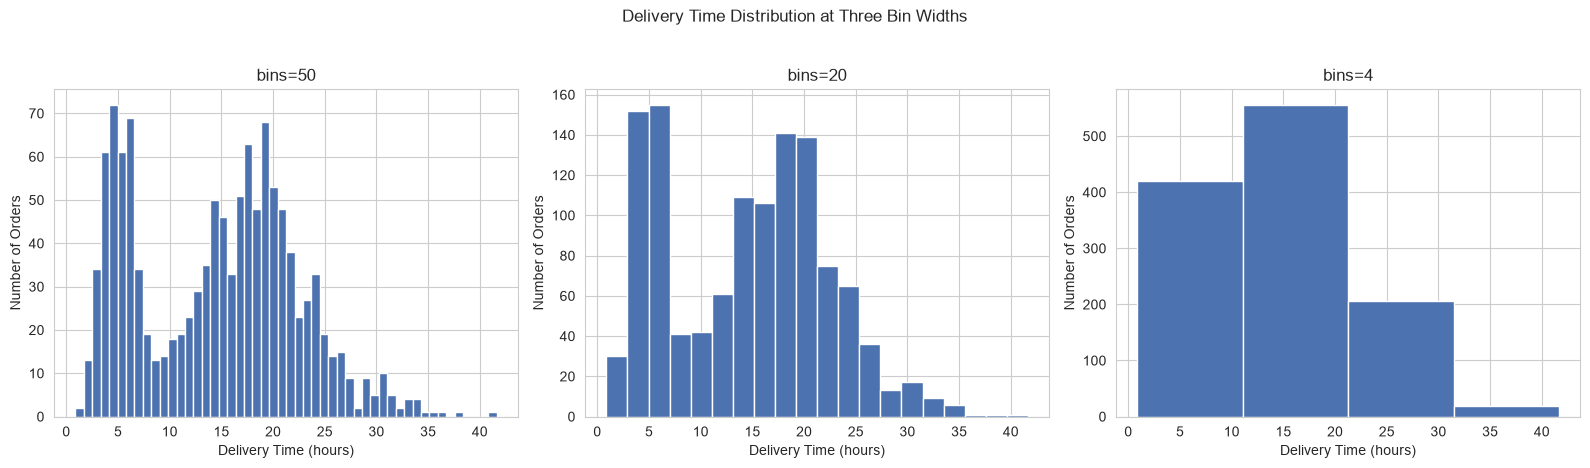

In [2]:
# TODO (done): compare three bin widths side by side -- small (50), moderate (20), large (4)
bin_options = [50, 20, 4]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, bins in zip(axes, bin_options):
    ax.hist(df["delivery_time_hours"], bins=bins, color="#4C72B0", edgecolor="white")
    ax.set_title(f"bins={bins}")
    ax.set_xlabel("Delivery Time (hours)")
    ax.set_ylabel("Number of Orders")

plt.suptitle("Delivery Time Distribution at Three Bin Widths", y=1.03)
plt.tight_layout()
plt.show()

**Question 1:** At a bin width that shows the clearest picture, does the data look like
a single smooth hump, or something else? What might explain that shape in a delivery
business (hint: think about whether QuickCart might offer more than one type of delivery
service)?

*Your answer:*

At `bins=20` (and even more clearly at `bins=50`), the distribution is **not** a single
smooth hump -- it's **bimodal**: a tight cluster of short delivery times around 3-7 hours,
and a wider, taller cluster spread roughly 10-25 hours. At `bins=4` the two clusters get
merged into what looks like one lumpy hump, which hides the real structure -- this is a
classic case of an over-wide bin washing out a meaningful pattern.

The most likely explanation is that QuickCart runs **two different delivery services**:
a fast **Express** tier (short, tightly-clustered times) and a slower **Standard** tier
(longer, more variable times). Averaging or summarizing this data as "one" delivery-time
distribution would be misleading -- the two service tiers behave like two separate
populations mixed into a single column.

## Task 2 — Density Plot & Bandwidth 

A histogram's bin width can hide or exaggerate structure. Let's check with a KDE curve,
where **bandwidth** plays the same role as bin width.

**Fill in the blank:** try `bw_adjust` values of `0.2`, `1.0`, and `2.5` (one at a time,
re-running the cell) and observe how the curve changes.

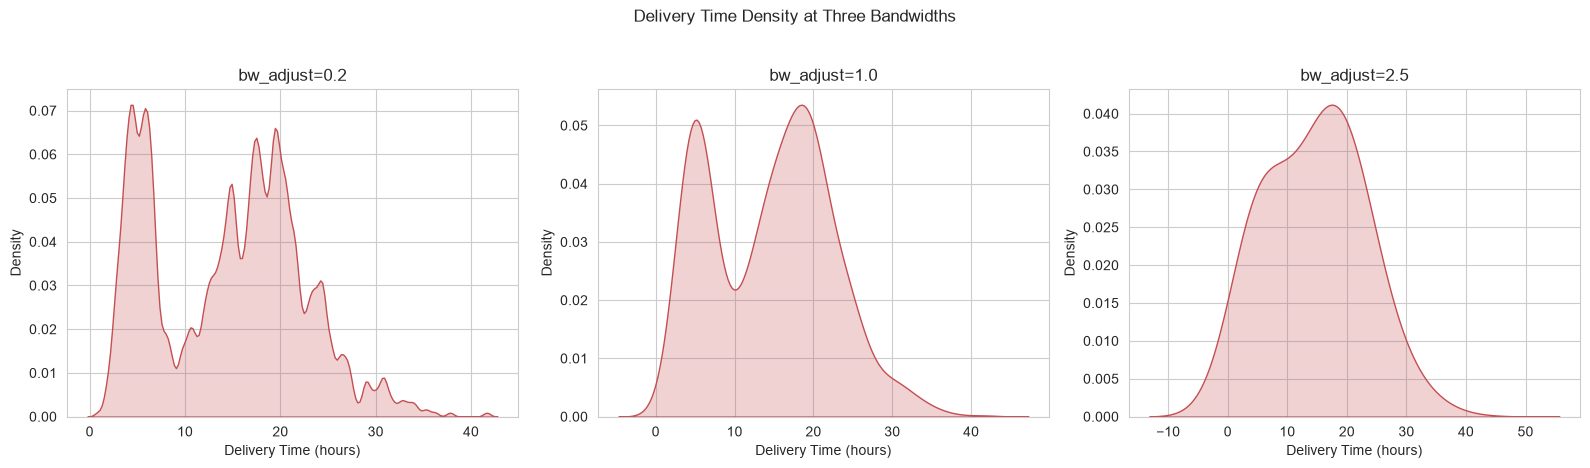

In [3]:
# TODO (done): compare three bandwidths side by side -- narrow (0.2), default (1.0), wide (2.5)
bw_options = [0.2, 1.0, 2.5]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, bw_adjust in zip(axes, bw_options):
    sns.kdeplot(df["delivery_time_hours"], bw_adjust=bw_adjust, fill=True, color="#C44E52", ax=ax)
    ax.set_title(f"bw_adjust={bw_adjust}")
    ax.set_xlabel("Delivery Time (hours)")
    ax.set_ylabel("Density")

plt.suptitle("Delivery Time Density at Three Bandwidths", y=1.03)
plt.tight_layout()
plt.show()

**Question 2:** At which `bw_adjust` value do you clearly see **two peaks** instead of
one? What does each peak most likely represent in QuickCart's delivery operations?
What would happen if an analyst only ever used a large bandwidth here -- what business
insight would they miss?

*Your answer:*

The two peaks are clearest at `bw_adjust=0.2` (and still visible, though softer, at the
default `1.0`). By `bw_adjust=2.5` the curve is over-smoothed into a single wide hump and
the second peak disappears entirely.

The left, narrow peak (~3-7 hours) represents **Express deliveries**; the right, broader
peak (~15-25 hours) represents **Standard deliveries** -- consistent with the histogram
in Task 1.

If an analyst only ever used a large bandwidth, they would see one smooth "average"
delivery-time curve and conclude QuickCart has one fairly consistent (if slow-ish)
delivery experience. They'd completely miss that **two operationally distinct services**
exist -- which matters because Express and Standard likely need different staffing,
SLAs, and pricing decisions. Over-smoothing here would hide a real business insight
behind a false sense of "it's all just one distribution."

## Task 3 — Proportions: Which region needs help? 

Now let's look at `delivery_status` (On Time / Delayed / Severely Delayed) across regions.

**Fill in the blank:** the code below builds the proportion table and three chart types.
Nothing to change here except reading the output carefully — but try commenting out one of
the three chart types (`axes[0]`, `axes[1]`, or `axes[2]`) to see how the layout responds.

In [4]:
status_by_region = (
    df.groupby("region")["delivery_status"]
    .value_counts(normalize=True)
    .unstack()
    .reindex(columns=["On Time", "Delayed", "Severely Delayed"])
)
status_by_region.round(2)

delivery_status,On Time,Delayed,Severely Delayed
region,,,
Central,0.35,0.41,0.24
East,0.33,0.51,0.16
North,0.38,0.45,0.17
South,0.04,0.42,0.54
West,0.35,0.45,0.20


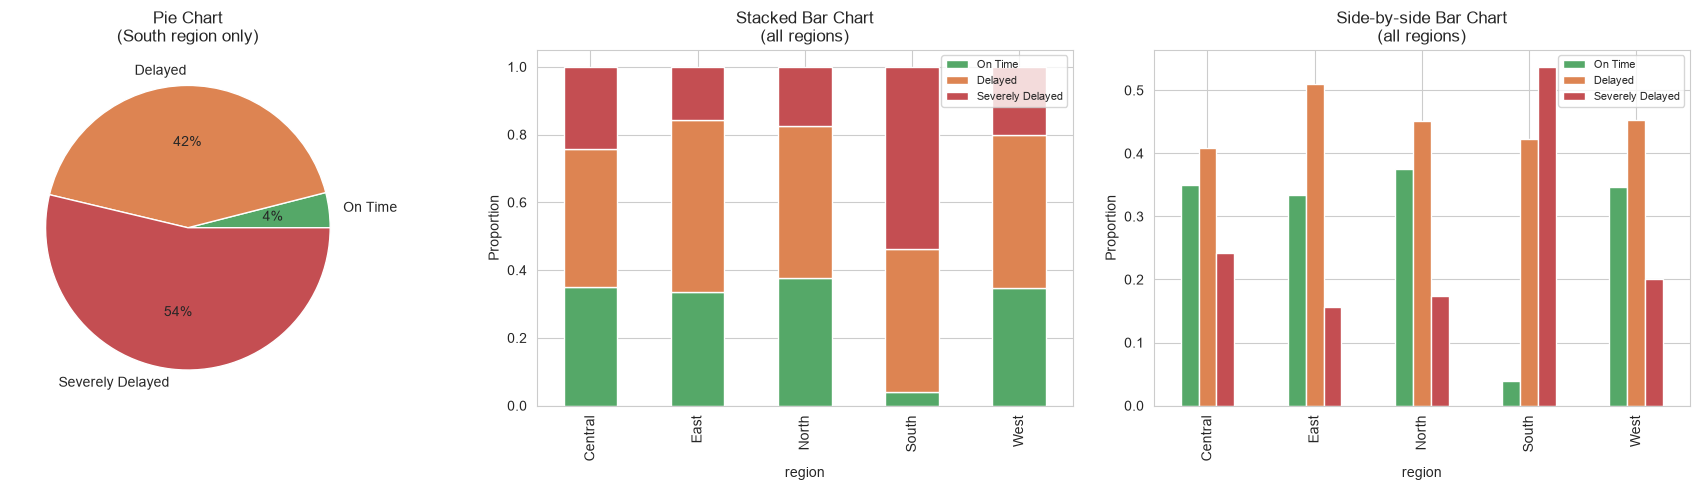

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie chart -- one region only, since pie charts don't compare groups well
axes[0].pie(status_by_region.loc["South"], labels=status_by_region.columns,
            autopct="%1.0f%%", colors=["#55A868", "#DD8452", "#C44E52"])
axes[0].set_title("Pie Chart\n(South region only)")

# Stacked bar -- all regions
status_by_region.plot(kind="bar", stacked=True, ax=axes[1],
                       color=["#55A868", "#DD8452", "#C44E52"])
axes[1].set_title("Stacked Bar Chart\n(all regions)")
axes[1].set_ylabel("Proportion")
axes[1].legend(fontsize=8)

# Side-by-side bar -- all regions
status_by_region.plot(kind="bar", stacked=False, ax=axes[2],
                       color=["#55A868", "#DD8452", "#C44E52"])
axes[2].set_title("Side-by-side Bar Chart\n(all regions)")
axes[2].set_ylabel("Proportion")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Question 3:** Which region has the worst delivery performance, and which chart made
that easiest to spot? Why would the pie chart alone (even one per region) be a poor choice
for comparing all five regions against each other?

*Your answer:*

**South** has the worst delivery performance -- it has the lowest "On Time" share and
the highest "Severely Delayed" share of all five regions (this matches how the data was
constructed: South deliveries get an extra +8 hour average delay on top of the base
delivery time).

The **side-by-side bar chart** makes this easiest to spot, because it lines up each
status category across all five regions at a shared baseline, so you can directly compare
bar heights region-by-region for the same status. The **stacked bar chart** is a close
second -- it shows the worsening "On Time" share shrinking for South -- but comparing
the *middle* segment of a stack across bars is harder than comparing bars from a common
baseline.

A pie chart alone -- even one per region -- is a poor choice for comparing all five
regions, because **each pie has no shared reference point with the others**. Human
perception is much worse at comparing angles/areas across separate pies than it is at
comparing bar lengths against one shared axis. To compare five regions with pie charts,
you'd need five separate pies and would have to eyeball-compare wedge sizes across
different circles -- exactly the kind of comparison bar charts are built to make easy
and pies are known to make hard.

## Wrap-up — Your Recommendation *(~3 min)*

Write a 2–3 sentence recommendation to the QuickCart ops team, combining **both** findings:
- What Task 1 & 2 revealed about delivery time structure (histogram + KDE + bandwidth)
- What Task 3 revealed about regional performance (proportions)

*Your recommendation:*

Delivery times are not one uniform pattern but a mix of two distinct services -- a fast
Express tier and a much slower, more variable Standard tier -- so any single average
delivery-time metric will misrepresent both groups; reporting and staffing should be
split by service tier rather than pooled together. Layered on top of that, the **South**
region is a clear outlier with the worst on-time rate and the highest share of severely
delayed orders, most visible in the side-by-side bar comparison. **Recommendation:**
prioritize additional delivery staff for the South region first, and when reporting
delivery-time KPIs going forward, break the numbers out by Express vs. Standard so the
faster tier's performance doesn't mask problems in the slower one.